В цьому домашньому завданні ми проведемо додаткові експерименти для рішення задачі бінарної класифікації і створимо ваш новий submission на змагання на Kaggle.

-----------


**Завдання 0**. Завантажте дані `train.csv`, `test.csv`, `sample_submission.csv` зі змагання на Kaggle - шукайте посилання в уроці [Запрошення до участі у Kaggle-змаганні.](https://data-loves.kwiga.com/courses/machine-learning-dlia-liudei/domashnie-zavdannia-zmagannia-z-kaggle)  Для завантаження потрібно долучитись до змагання (натиснути кнопку "Join").


**Завдання 1**. **Збираємо весь код з попереднього ДЗ в одному місці.** В лекційному ноутбуці `Логістична регресія з ScikitLearn. Повна ML задача.ipynb` ми познайомились з поняттям пайплайнів, а також я показала, як компактно виглядає рішення МЛ задачі, якщо ми зберемо весь код разом.

Оскільки ми далі будемо робити експерименти, які включають ті самі етапи попередньої обробки, але інше моделювання - буде зручно мати весь код компактно і під рукою. Тому зараз ми займемось збором коду до купи :) Після цього завдання для подальших експериментів ви можете перенести частини розвʼязку взагалі в окремий `.py` файл, аби було зручно імпортувати функції.

Зі свого рішення в попередньому домашньому завданні (`Логістична регресія з scikit learn.ipynb`) зберіть усі кроки розвʼязку задачі разом з використанням `sklearn.Pipeline` за прикладом з лекції.

Ваш код нижче має містити
1. Читання даних з файлу (поза пайплайном).
2. Розбиття на тренувальний і валідаційний набори, де валідаційний містить 20% даних (поза пайплайном).
3. Виділення категоріальних і числових колонок (поза пайплайном).
4. Підготовку категоріальних і числових колонок (частина пайплайну). В прикладі в лекції ми оформлювали обробку числових і категоріальних колонок в окремі трансформери `numeric_transformer`, `categorical_cols`. Рекоемндую зробити саме так, так потім зручніше вносити зміни :)
5. Тренування лог регресії (частина пайплайну).
6. Запуск пайплайну на тренування на трен. даних (поза пайплайном).
7. Запуск пайплайну на передбачення на трен і вал. даних і вимір метрик якості ROC-AUC + вивдення Confusion Matrix (поза пайплайном).
8. Збереження моделі в формат joblib (поза пайплайном).

Ви це все вже зробили в попереднтьому ДЗ! Тож, тут просто заадча все зібрати разом.

Нижче я додала підказки, що покроково ви маєте зробити. Якщо ви почуваєтесь впевнено, можете видалити ці підказки і реалізувати все самостійно, або ж - просто заповнити пропуски.

Завдання оцінюється в 10 балів. Головний результат - аби код в фіналі був робочий. Бо за не робочий нам гроші ніхто не заплатить :)

In [1]:
!pip install opendatasets

In [35]:
import opendatasets as od
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import confusion_matrix
from sklearn.metrics import root_mean_squared_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
from sklearn.preprocessing import PolynomialFeatures
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
import warnings

In [4]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [8]:
data_dir = ('/content/drive/MyDrive/Colab Notebooks/Machine Learning/bank-customer-churn-prediction-dlu-course-c-5')

print(os.listdir(data_dir))

['sample_submission.csv', 'test.csv', 'train.csv', 'log_reg.joblib', 'val_targets.parquet', 'val_inputs.parquet', 'train_inputs.parquet', 'train_targets.parquet']


In [9]:
train_path = os.path.join(data_dir, 'train.csv')
test_path = os.path.join(data_dir, 'test.csv')
submission_path = os.path.join(data_dir, 'sample_submission.csv')

raw_df = pd.read_csv(train_path)
test_raw_df = pd.read_csv(test_path)
sample_submission = pd.read_csv(submission_path)

print('Train shape:', raw_df.shape)
print('Test shape:', test_raw_df.shape)
print('Submission shape:', sample_submission.shape)

display(raw_df.head())

Train shape: (15000, 14)
Test shape: (10000, 13)
Submission shape: (10000, 2)


,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,0,15779985.0,Nwankwo,678.0,France,Male,29.0,4.0,0.00,3.0,1.0,0.0,180626.36,0.0
1,1,15650086.0,Ch'in,687.0,France,Female,34.0,1.0,0.00,2.0,0.0,1.0,63736.17,0.0
2,2,15733602.0,Thompson,682.0,France,Female,52.0,6.0,0.00,3.0,0.0,0.0,179655.87,1.0
3,3,15645794.0,Macleod,753.0,Germany,Male,44.0,6.0,83347.25,2.0,1.0,0.0,161407.48,0.0
4,4,15633840.0,Hsia,544.0,Germany,Female,55.0,0.0,107747.57,1.0,1.0,0.0,176580.86,1.0


Area under ROC score on Train dataset: 0.88%


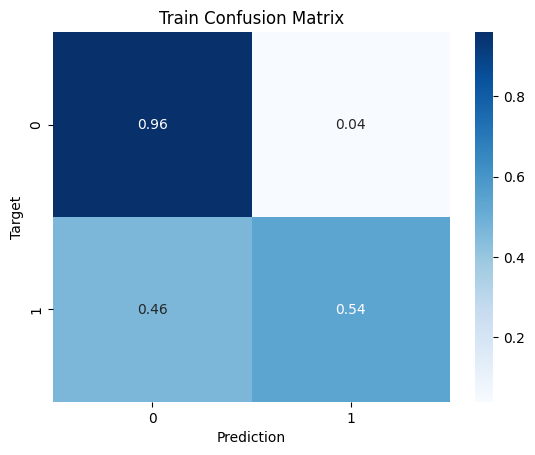

Area under ROC score on Validation dataset: 0.88%


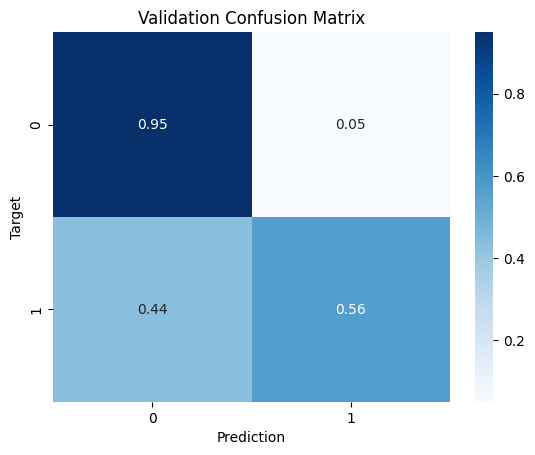

['bank_castomer_pipeline.joblib']

In [11]:
train_df, val_df = train_test_split(raw_df, test_size=0.2, random_state=42, stratify=raw_df['Exited'])

# Створюємо трен. і вал. набори
input_cols = train_df.columns.drop('Exited')
target_col = 'Exited'
train_inputs = train_df[input_cols]
train_targets = train_df[target_col]
val_inputs = val_df[input_cols]
val_targets = val_df[target_col]

# Видаляжмо колонки, які вважаємо не потрібними
train_inputs = train_inputs.drop(columns=['CustomerId', 'Surname'])
val_inputs = val_inputs.drop(columns=['CustomerId', 'Surname'])

# Виявляємо числові і категоріальні колонки
numeric_cols = train_inputs.select_dtypes(include=np.number).columns.difference(['id']).tolist()
categorical_cols = train_inputs.select_dtypes('object').columns.tolist()

# Створюємо трансформери для числових і категоріальних колонок
numeric_transformer = Pipeline(steps=[
    ('scaler', MinMaxScaler())
])

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(sparse_output=False, handle_unknown='ignore'))
])

# Комбінуємо трансформери для різних типів колонок в один препроцесор
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])

# Стоврюємо пайплайн, який спочатку запускає препроцесинг, потім тренуєм модель
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(solver='liblinear'))
])

# Тренуємо пайплайн
model_pipeline.fit(train_inputs, train_targets)

# Функція, щоб передбачати і рахувати метрики
def predict_and_plot(model_pipeline, inputs, targets, name=''):
    preds = model_pipeline.predict(inputs)
    y_pred_proba = model_pipeline.predict_proba(inputs)[:, 1]
    fpr, tpr, thresholds = roc_curve(targets, y_pred_proba)
    roc_auc = auc(fpr, tpr)
    print(f"Area under ROC score on {name} dataset: {roc_auc:.2f}%")
    confusion_matrix_ = confusion_matrix(targets, preds, normalize='true')
    plt.figure()
    sns.heatmap(confusion_matrix_, annot=True, cmap='Blues')
    plt.xlabel('Prediction')
    plt.ylabel('Target')
    plt.title('{} Confusion Matrix'.format(name))
    plt.show()
    return preds

# Оцінюємо модель на трен і вал даних
train_preds = predict_and_plot(model_pipeline,train_inputs, train_targets, 'Train')
val_preds = predict_and_plot(model_pipeline, val_inputs, val_targets, 'Validation')

# Зберігаємо модель для подальшого використання
joblib.dump(model_pipeline, 'bank_castomer_pipeline.joblib')


**Завдання 2**. Такс, у нас з вами є вже готовий пайплайн. Давайте проведемо нові експерименти.

  Додайте в попередню обробку числових колонок генерацію polinomal features до степені 2 включно. Для цього створіть новий препроцесор і створіть новий пайплайн.

  Запустіть пайплайн на тренування і виведіть метрики для тренувального і валідаційного набору. Напишіть, як вам модель? Чи спостерігається в цій моделі overfit чи underfit? Чи ця модель добре генералізує?

Модель з поліноміальними ознаками (степінь 2)
Area under ROC score on Train dataset: 0.92%


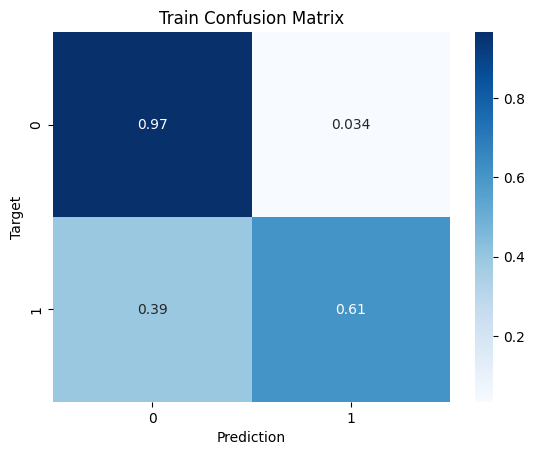

Area under ROC score on Validation dataset: 0.92%


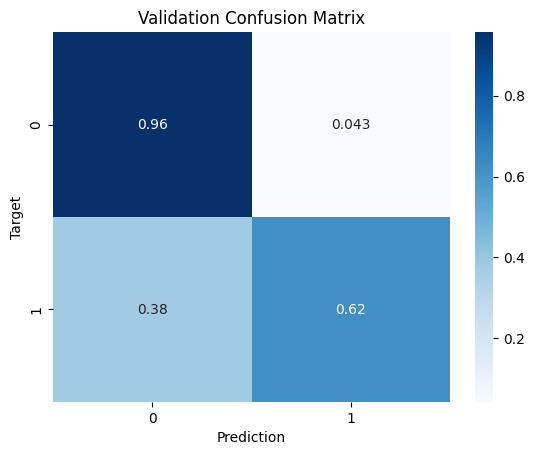

In [13]:
# Створюємо НОВИЙ трансформер для числових колонок (додаємо поліноми)
numeric_transformer_poly = Pipeline(steps=[
    ('scaler', MinMaxScaler()),
    ('poly', PolynomialFeatures(degree=2, include_bias=False))
])

# Створюємо НОВИЙ препроцесор
preprocessor_poly = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer_poly, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])

# Створюємо НОВИЙ загальний пайплайн
model_pipeline_poly = Pipeline(steps=[
    ('preprocessor', preprocessor_poly),
    ('classifier', LogisticRegression(solver='liblinear'))
])

# Тренуємо нову модель
model_pipeline_poly.fit(train_inputs, train_targets)

# Використовуємо функцію predict_and_plot для оцінки
print("Модель з поліноміальними ознаками (степінь 2)")
train_preds_poly = predict_and_plot(model_pipeline_poly, train_inputs, train_targets, 'Train')
val_preds_poly = predict_and_plot(model_pipeline_poly, val_inputs, val_targets, 'Validation')

Модель стала кращою! Метрика ROC-AUC зросла до 0.92 на тренувальному наборі і тримається на такому ж високому рівні на валідаційному. Це означає, що модель добре генералізує (здатна робити точні прогнози на нових даних). Ознак перенавчання (overfit) або недонавчання (underfit) не спостерігається, оскільки результати на обох вибірках високі і близькі один до одного

**Завдання 3**. Тепер давайте створимо ще новий пайплайн, тільки тепер поліноміальні ознаки згенеруємо до степені 4. Зробіть висновок про якість моделі. Якщо вам подобається резульат якоїсь з моделей в цьому ДЗ - рекомендую зробити submission в змаганні.

Модель з поліноміальними ознаками (степінь 4)
Area under ROC score on Train dataset: 0.93%


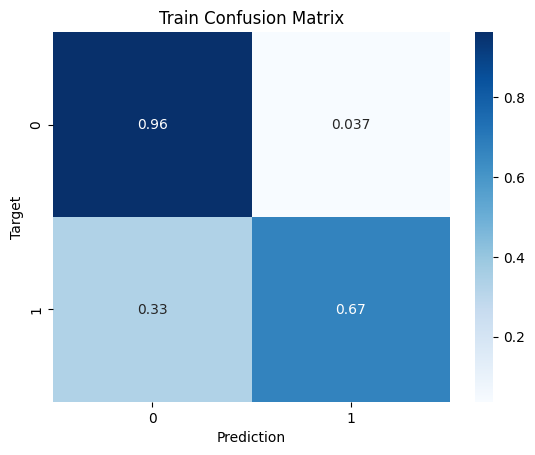

Area under ROC score on Validation dataset: 0.93%


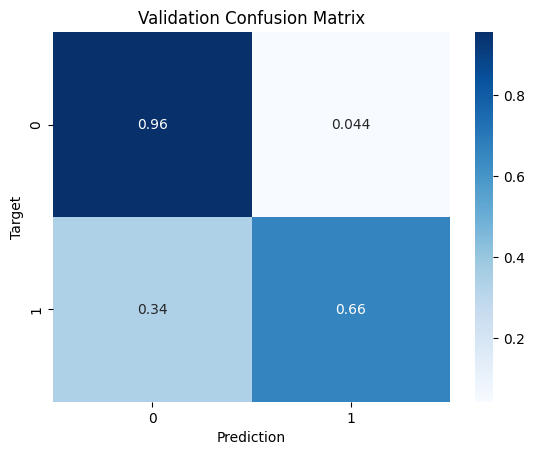

In [21]:
# Створюємо трансформер для числових колонок зі степенем 4
numeric_transformer_poly4 = Pipeline(steps=[
    ('scaler', MinMaxScaler()),
    ('poly', PolynomialFeatures(degree=4, include_bias=False))
])

# Створюємо новий препроцесор
preprocessor_poly4 = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer_poly4, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])

# Створюємо фінальний пайплайн
# Додаємо max_iter=1000, бо через велику кількість ознак моделі може знадобитись більше часу на навчання
model_pipeline_poly4 = Pipeline(steps=[
    ('preprocessor', preprocessor_poly4),
    ('classifier', LogisticRegression(solver='liblinear', max_iter=1000))
])

# Тренуємо модель
model_pipeline_poly4.fit(train_inputs, train_targets)

# Оцінюємо результати
print("Модель з поліноміальними ознаками (степінь 4)")
train_preds_poly4 = predict_and_plot(model_pipeline_poly4, train_inputs, train_targets, 'Train')
val_preds_poly4 = predict_and_plot(model_pipeline_poly4, val_inputs, val_targets, 'Validation')

In [18]:
test_df = pd.read_csv(test_path)
test_inputs = test_df.drop(columns=['CustomerId', 'Surname', 'id'], errors='ignore')
test_preds_proba = model_pipeline_poly4.predict_proba(test_inputs)[:, 1]
submission = pd.read_csv(submission_path)
submission['Exited'] = test_preds_proba
display(submission.head())
final_submission_path = os.path.join(data_dir, 'submission_poly4.csv')
submission.to_csv(final_submission_path, index=False)

,id,Exited
0,15000,0.078705
1,15001,0.020314
2,15002,0.070271
3,15003,0.397902
4,15004,0.025540


**Завдання 4. Перенавчання і регуляризація**.

  Скачайте набір даних `regression_data.csv`. Звичайте набір даних з `regression_data.csv`, розбийте на train і test (в тест 20%) і натренуйте модель лінійної регресії з масштабуванням числових ознак і поліноміальними ознаками до степені **5 включно**.

  Виміряйте якість прогностичної моделі і зробіть висновок, чи модель хороша, чи вона добре генералізує?


In [30]:
# Зчитуємо дані
reg_df = pd.read_csv('regression_data.csv')

# Розбиваємо на фічі та таргет
X = reg_df.drop(columns=['target'])
y = reg_df['target']

# Спліт на трейн і тест (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Створюємо пайплайн
reg_pipeline_deg5 = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('poly', PolynomialFeatures(degree=5, include_bias=False)),
    ('model', LinearRegression())
])

# Тренуємо
reg_pipeline_deg5.fit(X_train, y_train)

# Виводимо метрики
print(f"Train RMSE: {root_mean_squared_error(y_train, y_train_pred):.4f}")
print(f"Test RMSE: {root_mean_squared_error(y_test, y_test_pred):.4f}")
print(f"Train R^2: {r2_score(y_train, y_train_pred):.4f}")
print(f"Test R^2: {r2_score(y_test, y_test_pred):.4f}")

Train RMSE: 0.0000
Test RMSE: 35.6281
Train R^2: 1.0000
Test R^2: 0.4559


Модель абсолютно не вміє генералізувати. Спостерігається жорстке перенавчання (overfit): метрика R^2 на тренінгу дорівнює 1.0, але на тестових даних падає до 0.45. Це сталося через те, що звичайна лінійна регресія не має штрафів за занадто великі ваги, і велика кількість поліноміальних ознак 5-го ступеня змусила її просто запам'ятати тренувальний набір разом із його шумом.

**Завдання 5**. Натренуйте моделі Lasso(), Ridge(), ElasaticNet() на цих даних (з поліном ознаками до степені 20 включно), порівняйте якість з тою, яка була отримана з лінійною регресією. Яка модель найкраще генералізує і чому на ваш погляд (можливо треба буде для відповіді зробити додатковий аналіз ознак)?

In [36]:
warnings.filterwarnings('ignore')

In [32]:
models = {
    'Lasso': Lasso(random_state=42, max_iter=10000),
    'Ridge': Ridge(random_state=42),
    'ElasticNet': ElasticNet(random_state=42, max_iter=10000)
}

In [37]:
for name, model in models.items():
    pipeline = Pipeline(steps=[
        ('scaler', StandardScaler()),
        ('poly', PolynomialFeatures(degree=20, include_bias=False)),
        ('model', model)
    ])

    pipeline.fit(X_train, y_train)
    y_train_pred = pipeline.predict(X_train)
    y_test_pred = pipeline.predict(X_test)

    print(f"{name}")
    print(f"Train R^2: {r2_score(y_train, y_train_pred):.4f}")
    print(f"Test R^2: {r2_score(y_test, y_test_pred):.4f}")
    print(f"Test RMSE: {root_mean_squared_error(y_test, y_test_pred):.4f}\n")

Lasso
Train R^2: 0.9974
Test R^2: -3.6737
Test RMSE: 104.4228

Ridge
Train R^2: 0.4883
Test R^2: -15796213.7369
Test RMSE: 191972.9243

ElasticNet
Train R^2: 0.9570
Test R^2: -674.4713
Test RMSE: 1255.3561



Поліноміальні ознаки 20-го ступеня створюють надмірну кількість мультиколінеарного шуму, через що всі моделі мають від'ємний $R^2$ на тестовій вибірці (тобто жодна не генералізує добре в абсолютних значеннях).

Проте найкраще з цим хаосом впоралася модель Lasso. Її метрики деградації набагато менші, ніж у Ridge. Це відбувається завдяки природі $L_1$ регуляризації: Lasso вміє проводити відбір ознак (feature selection) і жорстко зануляти ваги неінформативних колонок. Він просто відкинув більшість створених поліномів як зайвий шум.

Модель Ridge, навпаки, повністю зламалася ($R^2$ впав до мільйонних від'ємних значень), оскільки вона лише зменшує ваги, але не прибирає їх повністю, що призводить до катастрофічного перенавчання на такій кількості ознак.